# Anthropic compute from cloud spend

Anthropic's compute estimated from its reported cloud spending: \$2.5B in 2024 and \$6.8B in 2025 (The Information).

**Part A (sections 1–4): the canonical end-2024 estimate.** No power figure exists for end-2024, so spending is converted directly: fit a spending-rate curve to the two annual totals, read off the rate at end-2024, and divide by the 2024 cost of an H100e-hour. Priors are in `lab_model_params.csv`; `model_anthropic_2024()` in the frontier script implements the same model and section 2 checks the two match. Section 3 is an experimental alternative, backcasting the end-2025 power-model fleet, kept as a cross-check.

**Part B (sections 5–12): an end-2025 cross-check.** The same dollars pointed at 2025: a two-bucket model (Nvidia at market rental rates, Trainium2 at Amazon's cost plus a markup) of what \$6.8B bought. The canonical end-2025 model is `anthropic_power_2025`; Part B's priors are notebook literals.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import squigglepy as sq

# The frontier script and shared modules live at the repo root, one level up
# from notebooks/.
sys.path.insert(0, str(Path('..').resolve()))
import frontier_lab_compute_model as frontier
from lab_compute_utils import load_lab_params

N_SAMPLES = 5000
HOURS_PER_YEAR = 8760

def fmt(value):
    """Format an H100e count as a short string (millions or thousands)."""
    if abs(value) >= 1e6:
        return f'{value / 1e6:.2f}M'
    return f'{value / 1e3:,.0f}k'

def percentiles(samples):
    """Return (5th, 50th, 95th) percentiles of a sample array."""
    p = sq.get_percentiles(samples, percentiles=[5, 50, 95])
    return p[5], p[50], p[95]

def show(label, samples):
    lo, mid, hi = percentiles(samples)
    print(f'   {label:34s}: {fmt(lo)} / {fmt(mid)} / {fmt(hi)}')

## 1. The spending trajectory

Anthropic reportedly spent \$2.5B on cloud compute in 2024 and \$6.8B in 2025 (The Information). Those are full-year totals; the goal here is the *rate* of spending at the end of 2024, which is what converts to a fleet size. The two totals are sampled as correlated lognormals (both come from the same reporting).

If the spending rate grows exponentially, the ratio of the two totals fixes the average growth rate (~2.7× per year) but not *when* within each year the money arrived. The **growth-shape factor** handles this. It scales the within-2025 growth rate relative to that average:

- **shape 1**: one smooth exponential through both years;
- **shape below 1 (front-loaded)**: 2025's spending arrived early, so the year had to *start* at a high rate. That means a steep 2024 ramp and a high end-2024 rate;
- **shape above 1 (back-loaded)**: 2025's ramp was steep, so the year started low. 2024 is nearly flat and the end-2024 rate is low.

The end-2024 rate is the end-2025 rate divided by one year of within-2025 growth, so the shape factor is what sets it. No 2023 data is needed.

The chart below draws three spending paths that hit the same two annual totals (equal areas under each curve over each year) and differ only in shape; the end-2024 rate is where each crosses the year boundary. Two reference points are overlaid: SemiAnalysis's quarterly Anthropic cost build (calibrated to the same annual totals, so it speaks to shape rather than level) and the WSJ's reported Q1-2026 compute and infrastructure cost of \$3.4B (~\$13.6B/yr). The quarterly build tracks the smooth curve through 2024 and runs a little steeper through 2025, equivalent to a shape of ~1.3.

Prior: 90% CI 0.9–1.5.

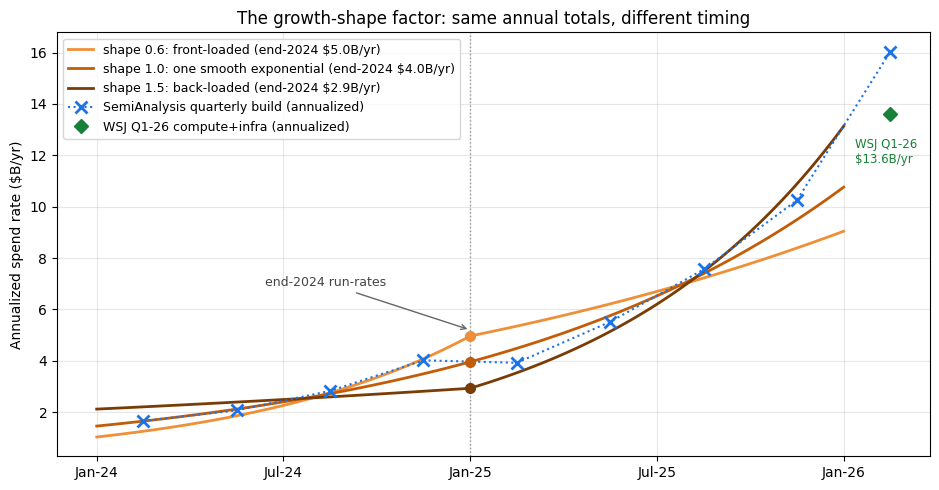

In [2]:
# SemiAnalysis's Anthropic financial model, quarterly training costs + inference
# COGS ($M), annualized at quarter midpoints. Calibrated to the same anchors
# (annual spend totals, ~1.4 GW end-2025), so it cross-checks the within-year
# shape rather than the level. Q1-2026 included for context on where the ramp
# goes next.
SA_QUARTERS = {
    2024.125: 300 + 114, 2024.375: 350 + 167, 2024.625: 400 + 306, 2024.875: 575 + 429,
    2025.125: 750 + 230, 2025.375: 950 + 429, 2025.625: 1150 + 739, 2025.875: 1400 + 1163,
    2026.125: 2054 + 1956,
}
sa_x = list(SA_QUARTERS)
sa_y = [v * 4 / 1e3 for v in SA_QUARTERS.values()]

# WSJ-reported Q1-2026 compute and infrastructure costs ($M for the quarter),
# annualized the same way. A reported figure, not a model build; its definition
# may not match SA's training + inference COGS exactly.
WSJ_Q1_2026_COSTS = 3400
wsj_x, wsj_y = 2026.125, WSJ_Q1_2026_COSTS * 4 / 1e3

# Illustration curves: the reported totals treated as exact. Each curve
# integrates to the 2024 total over 2024 and the 2025 total over 2025; the 2024
# segment gets its own growth rate, solved so its area comes out right given
# the rate it must reach at the year boundary.
ILLUS_2024_TOTAL, ILLUS_2025_TOTAL = 2.5, 6.8
illus_avg_growth = np.log(ILLUS_2025_TOTAL / ILLUS_2024_TOTAL)

def solve_2024_growth(boundary_rate):
    """Within-2024 growth rate that ends the year at the boundary rate while
    integrating to the 2024 total (bisection; the integrated fraction of the
    boundary rate falls monotonically as growth speeds up)."""
    target = ILLUS_2024_TOTAL / boundary_rate
    lo, hi = 1e-9, 20.0
    for _ in range(100):
        mid = (lo + hi) / 2
        if (1 - np.exp(-mid)) / mid > target:
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2

fig, ax = plt.subplots(figsize=(9.5, 5))
t = np.linspace(0, 1, 101)
# The shape curves are one family (a swept parameter), so they share a hue as a
# light-to-dark ramp; blue and green stay reserved for the external evidence.
for shape, color, note in [(0.6, '#ef8f38', 'front-loaded'),
                           (1.0, '#c25c07', 'one smooth exponential'),
                           (1.5, '#7a3c05', 'back-loaded')]:
    growth_2025 = illus_avg_growth * shape
    # Where the 2025 exponential must start so its area is the 2025 total.
    boundary_rate = ILLUS_2025_TOTAL * growth_2025 / (np.exp(growth_2025) - 1)
    growth_2024 = solve_2024_growth(boundary_rate)
    ax.plot(2024 + t, boundary_rate * np.exp(-growth_2024 * (1 - t)), color=color, lw=2)
    ax.plot(2025 + t, boundary_rate * np.exp(growth_2025 * t), color=color, lw=2,
            label=f'shape {shape}: {note} (end-2024 ${boundary_rate:.1f}B/yr)')
    ax.plot(2025, boundary_rate, 'o', color=color, markersize=7, zorder=5)
ax.plot(sa_x, sa_y, marker='x', ls=':', color='#1a73e8', markersize=8, mew=2,
        label='SemiAnalysis quarterly build (annualized)')
ax.plot(wsj_x, wsj_y, marker='D', ls='none', color='#188038', markersize=7,
        label='WSJ Q1-26 compute+infra (annualized)')
ax.annotate(f'WSJ Q1-26\n${wsj_y:.1f}B/yr', xy=(wsj_x, wsj_y),
            xytext=(wsj_x - 0.095, wsj_y - 1.9), fontsize=8.5, color='#188038')
ax.axvline(2025, color='#999999', lw=1, ls=':')
ax.annotate('end-2024 run-rates', xy=(2025.0, 5.2), xytext=(2024.45, 6.9), fontsize=9,
            color='#444444', arrowprops=dict(arrowstyle='->', color='#666666', lw=1))
ax.set_xticks([2024, 2024.5, 2025, 2025.5, 2026])
ax.set_xticklabels(['Jan-24', 'Jul-24', 'Jan-25', 'Jul-25', 'Jan-26'])
ax.set_ylabel('Annualized spend rate ($B/yr)')
ax.set_title('The growth-shape factor: same annual totals, different timing', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Sampling the trajectory

The run-rate curve sampled from the sheet priors, against the same two reference points.

In [3]:
# Priors from the sheet, sampled in the same order as the frontier script's
# model_anthropic_2024 under the same seed, so the two match exactly. (The
# spend totals are correlated in code — the sheet can't express correlations.)
sq.set_seed(42)
PARAMS = load_lab_params()['anthropic']

spend24_dist, spend25_dist = sq.correlate(
    (PARAMS['cloud_spend_2024'], PARAMS['cloud_spend_2025']), 0.5)
spend_2024_total = (spend24_dist @ N_SAMPLES) * 1e9
spend_2025_total = (spend25_dist @ N_SAMPLES) * 1e9
avg_growth = np.log(spend_2025_total / spend_2024_total)
growth_shape = PARAMS['spend_growth_shape_2025'] @ N_SAMPLES
inst_rate = avg_growth * growth_shape

# Year-end annualized run-rates of the exponential that integrates to the 2025
# total; the start-2025 rate is the end-2024 rate.
runrate_2025_end = spend_2025_total * inst_rate / (1 - np.exp(-inst_rate))
runrate_ratio = np.exp(-inst_rate)
runrate_2024_end = runrate_2025_end * runrate_ratio

print('Spending trajectory (5th / median / 95th):')
lo, mid, hi = percentiles(spend_2024_total)
print(f'   2024 full-year total ($B):        {lo / 1e9:.2f} / {mid / 1e9:.2f} / {hi / 1e9:.2f}')
lo, mid, hi = percentiles(spend_2025_total)
print(f'   2025 full-year total ($B):        {lo / 1e9:.2f} / {mid / 1e9:.2f} / {hi / 1e9:.2f}')
lo, mid, hi = percentiles(np.exp(avg_growth))
print(f'   2024->2025 avg growth factor:     {lo:.2f} / {mid:.2f} / {hi:.2f}')
lo, mid, hi = percentiles(growth_shape)
print(f'   growth shape (1 = smooth ramp):   {lo:.2f} / {mid:.2f} / {hi:.2f}')
lo, mid, hi = percentiles(runrate_2025_end)
print(f'   end-2025 spending rate ($B/yr):   {lo / 1e9:.1f} / {mid / 1e9:.1f} / {hi / 1e9:.1f}')
lo, mid, hi = percentiles(runrate_2024_end)
print(f'   end-2024 spending rate ($B/yr):   {lo / 1e9:.1f} / {mid / 1e9:.1f} / {hi / 1e9:.1f}')
lo, mid, hi = percentiles(runrate_ratio)
print(f'   => spending-rate ratio (24/25):   {lo:.2f} / {mid:.2f} / {hi:.2f}')

Spending trajectory (5th / median / 95th):
   2024 full-year total ($B):        2.07 / 2.50 / 2.99
   2025 full-year total ($B):        5.66 / 6.78 / 8.18
   2024->2025 avg growth factor:     2.27 / 2.73 / 3.27
   growth shape (1 = smooth ramp):   0.90 / 1.16 / 1.51
   end-2025 spending rate ($B/yr):   8.9 / 11.5 / 15.2
   end-2024 spending rate ($B/yr):   2.7 / 3.6 / 4.5
   => spending-rate ratio (24/25):   0.20 / 0.31 / 0.43


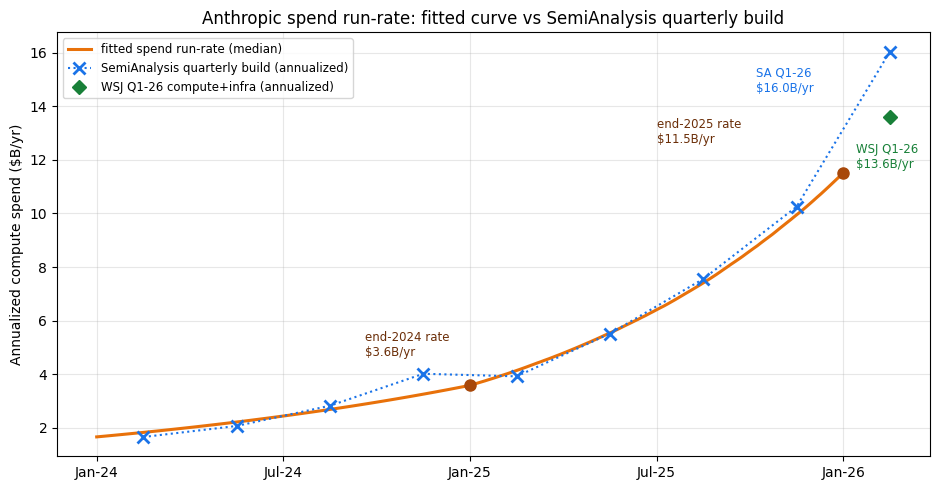

In [4]:
fig, ax = plt.subplots(figsize=(9.5, 5))

# The fitted spend curve: over 2025, the pointwise median of the per-sample
# fitted paths (so it passes through both year-end medians); over 2024, a
# segment solved to integrate to the 2024 total, exactly as in the shape chart.
u = np.linspace(0, 1, 101)
paths = runrate_2024_end[:, None] * np.exp(np.outer(inst_rate, u))
med_path = np.median(paths, axis=0)
boundary = med_path[0]
growth_2024_fit = solve_2024_growth(boundary / 1e9)  # the solver works in $B
ax.plot(2024 + u, boundary * np.exp(-growth_2024_fit * (1 - u)) / 1e9,
        color='#e8710a', lw=2.2)
ax.plot(2025 + u, med_path / 1e9, color='#e8710a', lw=2.2,
        label='fitted spend run-rate (median)')

# The two year-end rates the backcast actually uses. The end-2025 label sits
# further left so the SemiAnalysis line rising to Q1-26 doesn't run through it.
for x, samples, label, dx in [(2025.0, runrate_2024_end, 'end-2024 rate', -0.28),
                              (2026.0, runrate_2025_end, 'end-2025 rate', -0.50)]:
    mid = float(np.median(samples))
    ax.plot(x, mid / 1e9, 'o', color='#a8480a', markersize=8, zorder=5)
    ax.annotate(f'{label}\n${mid / 1e9:.1f}B/yr', xy=(x, mid / 1e9),
                xytext=(x + dx, mid / 1e9 + 1.1), fontsize=8.5, color='#6b2e08')

ax.plot(sa_x, sa_y, marker='x', ls=':', color='#1a73e8', markersize=8, mew=2,
        label='SemiAnalysis quarterly build (annualized)')
ax.annotate(f'SA Q1-26\n${sa_y[-1]:.1f}B/yr', xy=(sa_x[-1], sa_y[-1]),
            xytext=(sa_x[-1] - 0.36, sa_y[-1] - 1.5), fontsize=8.5, color='#1a73e8')

ax.plot(wsj_x, wsj_y, marker='D', ls='none', color='#188038', markersize=7,
        label='WSJ Q1-26 compute+infra (annualized)')
ax.annotate(f'WSJ Q1-26\n${wsj_y:.1f}B/yr', xy=(wsj_x, wsj_y),
            xytext=(wsj_x - 0.09, wsj_y - 1.9), fontsize=8.5, color='#188038')

ax.set_xticks([2024, 2024.5, 2025, 2025.5, 2026])
ax.set_xticklabels(['Jan-24', 'Jul-24', 'Jan-25', 'Jul-25', 'Jan-26'])
ax.set_ylabel('Annualized compute spend ($B/yr)')
ax.set_title('Anthropic spend run-rate: fitted curve vs SemiAnalysis quarterly build', fontsize=12)
ax.legend(loc='upper left', fontsize=8.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. The mainline estimate: dollars into chips at 2024 prices

A rented chip billed around the clock costs its hourly rate × 8,760 per year, so the end-2024 fleet is the end-2024 spending rate divided by the annual cost of one H100e.

Price prior: \$1.50–2.50 per H100e-hour. Anthropic's 2024 fleet was Hopper on long-term contracts plus a TPU v5e slice (no Trainium2 yet). One-year H100 contracts ran ~\$3/hr in 2023 and the low \$2s through 2024, with multi-year terms below that; the upper end allows for "compute spend" including storage, networking, and CPU costs beyond GPU-hours.

In [5]:
price_2024 = PARAMS['effective_price_2024'] @ N_SAMPLES  # $ per H100e-hour

h100e_direct = runrate_2024_end / (price_2024 * HOURS_PER_YEAR)
# The canonical export; lab_2024_backcasts reads model_anthropic_2024 directly.
anthropic_2024 = h100e_direct

print('The direct conversion (5th / median / 95th):')
lo, mid, hi = percentiles(price_2024)
print(f'   2024 price ($/H100e-hr):        {lo:.2f} / {mid:.2f} / {hi:.2f}')
show('END-2024 H100e (HEADLINE)', h100e_direct)

The direct conversion (5th / median / 95th):
   2024 price ($/H100e-hr):        1.51 / 1.95 / 2.52
   END-2024 H100e (HEADLINE)         : 145k / 209k / 298k


In [6]:
# Cross-check: the canonical frontier-script function reseeds and samples the
# same priors in the same order, so it must reproduce these samples exactly.
assert np.allclose(frontier.model_anthropic_2024(), h100e_direct)
print('matches frontier_lab_compute_model.model_anthropic_2024 exactly')

matches frontier_lab_compute_model.model_anthropic_2024 exactly


## 3. Experimental cross-check: backcasting the end-2025 fleet

Not used for the headline. This route starts from the power model's end-2025 fleet and shrinks it twice:

> end-2024 fleet = end-2025 fleet × spending ratio × price ratio

- **Spending ratio**: end-2024 rate over end-2025 rate, from the section 1 curve (median ~0.31).
- **Price ratio**: how much cheaper an H100e-hour was at end-2025 than in 2024. The 2025 price blends Nvidia at \$1.3–1.8 per H100e-hour with Trainium2 at Amazon's ~\$0.66/chip-hour cost times a 1.0–1.6× markup (~\$1.0–1.6 per H100e-hour), Trainium2 taking 40–70% of spend. The 2024 price and the 2025 Nvidia price are correlated (0.5); the ratio is capped at 0.9.

These priors are notebook literals. The end-2025 anchor is the frontier script's power model; its samples are shuffled and this route's inputs drawn from a separate seed so the two are independent.

In [7]:
openai_res = frontier.model_openai()   # Anthropic borrows Nvidia specs from this
anthropic_2025 = frontier.model_anthropic(openai_res)
anthropic_2025 = anthropic_2025[np.random.default_rng(123).permutation(N_SAMPLES)]

sq.set_seed(2024)  # this route's own draws, independent of the frontier streams

print('End-2025 anchor (canonical power model):')
show('Anthropic end-2025 H100e', anthropic_2025)

End-2025 anchor (canonical power model):
   Anthropic end-2025 H100e          : 842k / 1.19M / 1.72M


In [8]:
# This route's own 2024-price draw: the same sheet prior as the headline's,
# but drawn jointly with the 2025 Nvidia blend so the two stay correlated
# (sq.correlate ties the objects it is given, so fresh copies are loaded).
P2 = load_lab_params()['anthropic']
price_2024_r2_dist, nvidia_price_2025_dist = sq.correlate(
    (P2['effective_price_2024'], sq.to(1.3, 1.8)), 0.5)
price_2024_r2 = price_2024_r2_dist @ N_SAMPLES
nvidia_price_2025 = nvidia_price_2025_dist @ N_SAMPLES

# The two 2025 price buckets, $ per H100e-hour.
TRAINIUM2_H100E = 1299 / 1979  # dense BF16 FLOP/s ratio vs the H100
trainium_price_2025 = 0.66 * (sq.to(1.0, 1.6) @ N_SAMPLES) / TRAINIUM2_H100E
trainium_share = sq.to(0.40, 0.70) @ N_SAMPLES  # Trainium2 share of 2025 spend

# Blend by spend share: a dollar buys 1/price of compute in whichever bucket it lands.
h100e_hours_per_dollar = (
    trainium_share / trainium_price_2025 + (1 - trainium_share) / nvidia_price_2025)
price_2025 = 1 / h100e_hours_per_dollar

# Cheaper 2025 dollars mean the fleet shrank less than spending did. The cap
# rules out worlds where 2025 compute wasn't at least ~10% cheaper.
price_ratio = np.minimum(price_2025 / price_2024_r2, 0.9)
h100e_backcast = anthropic_2025 * runrate_ratio * price_ratio

print('The experimental backcast (5th / median / 95th):')
for name, arr in [('2025 Nvidia blend ($/H100e-hr)', nvidia_price_2025),
                  ('2025 Trainium2 ($/H100e-hr)', trainium_price_2025),
                  ('2025 blended price ($/H100e-hr)', price_2025),
                  ('spending ratio (end-24 / end-25)', runrate_ratio),
                  ('price ratio (2025 / 2024 price)', price_ratio)]:
    lo, mid, hi = percentiles(arr)
    print(f'   {name:33s}: {lo:.2f} / {mid:.2f} / {hi:.2f}')
show('END-2024 H100e (backcast)', h100e_backcast)

The experimental backcast (5th / median / 95th):
   2025 Nvidia blend ($/H100e-hr)   : 1.30 / 1.53 / 1.80
   2025 Trainium2 ($/H100e-hr)      : 1.01 / 1.27 / 1.60
   2025 blended price ($/H100e-hr)  : 1.17 / 1.38 / 1.60
   spending ratio (end-24 / end-25) : 0.20 / 0.31 / 0.43
   price ratio (2025 / 2024 price)  : 0.54 / 0.71 / 0.90
   END-2024 H100e (backcast)         : 144k / 260k / 456k


## 4. How the cross-check lands

The two routes share the spending trajectory and the 2024 price prior and differ in what sets the level: the 2024 price, or the power model's end-2025 fleet. The backcast's median runs ~1.2× the headline, equivalent to an effective 2024 price of ~\$1.58/H100e-hour, inside the prior.

In [9]:
print('Headline vs the experimental cross-check (5th / median / 95th):')
show('HEADLINE: direct at 2024 prices', h100e_direct)
show('experimental: backcast from end-2025', h100e_backcast)

route_gap = float(np.median(h100e_backcast)) / float(np.median(h100e_direct))
implied_price_2024 = float(np.median(runrate_2024_end)) / (
    float(np.median(h100e_backcast)) * HOURS_PER_YEAR)
print(f'\n   backcast / headline (medians): {route_gap:.2f}x')
print(f'   effective 2024 price implied by the backcast: ${implied_price_2024:.2f}/H100e-hr'
      f' (vs ${float(np.median(price_2024)):.2f} sticker prior)')

Headline vs the experimental cross-check (5th / median / 95th):
   HEADLINE: direct at 2024 prices   : 145k / 209k / 298k
   experimental: backcast from end-2025: 144k / 260k / 456k

   backcast / headline (medians): 1.25x
   effective 2024 price implied by the backcast: $1.57/H100e-hr (vs $1.95 sticker prior)


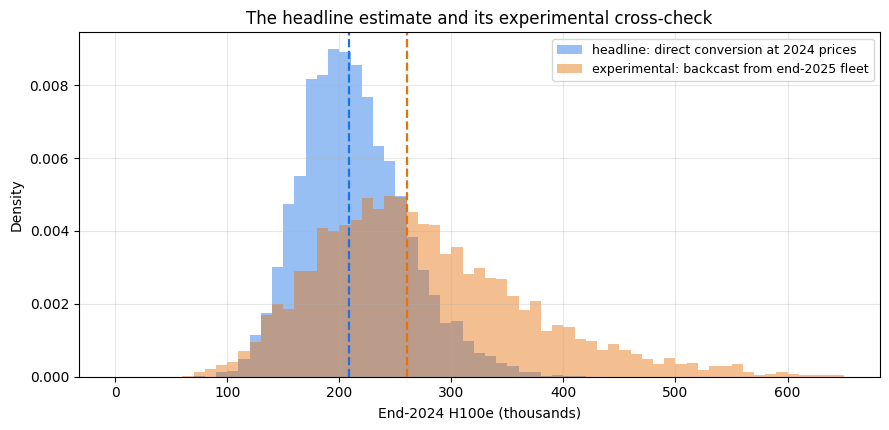

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.4))
bins = np.linspace(0, 650, 66)
for samples, color, label in [
        (h100e_direct, '#1a73e8', 'headline: direct conversion at 2024 prices'),
        (h100e_backcast, '#e8710a', 'experimental: backcast from end-2025 fleet')]:
    ax.hist(samples / 1e3, bins=bins, density=True, alpha=0.45, color=color, label=label)
    ax.axvline(float(np.median(samples)) / 1e3, color=color, lw=1.6, ls='--')
ax.set_xlabel('End-2024 H100e (thousands)')
ax.set_ylabel('Density')
ax.set_title('The headline estimate and its experimental cross-check', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

# Part B: the end-2025 cloud-spend cross-check

An alternate estimate of Anthropic's end-2025 compute from the \$6.8B of 2025 cloud spend. The natural output is a 2025 full-year average; section 12 rescales it to an end-2025 snapshot with the year-end run-rate from section 1.

The fleet is two buckets (TPU ignored):

- **Nvidia**: Hopper + Blackwell in the OpenAI model's count mix, priced at market rental rates.
- **Trainium2**: priced at Amazon's total cost of ownership (\$0.66/chip-hour, SemiAnalysis) times an uncertain cloud markup.

The Trainium2 share of spend is the main lever, so the model runs at a central share and then sweeps it.

In [11]:
BUCKET_COLORS = {'Hopper': '#76b900', 'Blackwell': '#1a73e8', 'Trainium2': '#e8710a'}
sq.set_seed(2025)  # part B's own draws, independent of parts A's streams

Generator(PCG64) at 0x1402CC040

## 5. Chip specs and the Hopper:Blackwell ratio

Per-chip H100e and OpenAI's end-2025 Hopper:Blackwell count ratio are read off the canonical OpenAI run (A100 dropped, GB300 folded into Blackwell).

In [12]:
openai_counts = openai_res['counts']
oai_h100e = openai_res['h100e_per_gpu']  # the model calls Blackwell "B200"

# OpenAI's end-2025 Hopper vs Blackwell chip counts (median across its Monte
# Carlo), A100 dropped. This ratio is what we borrow for Anthropic's Nvidia mix.
hopper_units = float(np.median(openai_counts['H100/H200']))
blackwell_units = float(np.median(openai_counts['B200'] + openai_counts['B300']))
hopper_per_blackwell = hopper_units / blackwell_units  # Hopper chips per 1 Blackwell

# Per-chip H100e for the two Nvidia buckets; TRAINIUM2_H100E was set in section 3.
HOPPER_H100E = oai_h100e['H100/H200']
BLACKWELL_H100E = oai_h100e['B200']

print('Borrowed from OpenAI end-2025 fleet (A100 dropped, GB300 folded into Blackwell):')
print(f'   Hopper    : {HOPPER_H100E:.3f} H100e/chip')
print(f'   Blackwell : {BLACKWELL_H100E:.3f} H100e/chip')
print(f'   Hopper:Blackwell count ratio = {hopper_per_blackwell:.2f} : 1')
print(f'   Trainium2 : {TRAINIUM2_H100E:.3f} H100e/chip (independent spec)')

Borrowed from OpenAI end-2025 fleet (A100 dropped, GB300 folded into Blackwell):
   Hopper    : 1.000 H100e/chip
   Blackwell : 2.527 H100e/chip
   Hopper:Blackwell count ratio = 1.48 : 1
   Trainium2 : 0.656 H100e/chip (independent spec)


## 6. Pricing

Nvidia rental rates (\$/GPU-hour), correlated so a high-price world lifts both: Hopper \$1.50–2.00, Blackwell \$3.00–4.00 (SemiAnalysis's Aug-2025 3-year-contract survey at the low end, the Silicon Data spot index at the high end).

Trainium2: Amazon's \$0.66/chip-hour cost times a markup with 90% CI 1.0–1.6× (near-cost access at the low end, a normal cloud margin at the high end).

In [13]:
TRAINIUM2_TCO = 0.66  # $/chip-hour, Amazon's cost (SemiAnalysis)

# Correlated Nvidia rental prices ($/GPU-hour).
hopper_price_dist, blackwell_price_dist = sq.correlate(
    (sq.to(1.50, 2.00), sq.to(3.00, 4.00)), 0.8)
hopper_price = hopper_price_dist @ N_SAMPLES
blackwell_price = blackwell_price_dist @ N_SAMPLES

# Trainium2 price to Anthropic = Amazon's TCO times an uncertain cloud markup.
trainium_markup = sq.to(1.0, 1.6) @ N_SAMPLES
trainium_price = TRAINIUM2_TCO * trainium_markup

print('Prices to Anthropic ($/chip-hour), 5th / median / 95th:')
for name, arr in [('Hopper', hopper_price), ('Blackwell', blackwell_price),
                  ('Trainium2', trainium_price)]:
    lo, mid, hi = percentiles(arr)
    print(f'   {name:10s}: {lo:.2f} / {mid:.2f} / {hi:.2f}')

Prices to Anthropic ($/chip-hour), 5th / median / 95th:
   Hopper    : 1.50 / 1.73 / 2.00
   Blackwell : 2.99 / 3.48 / 4.01
   Trainium2 : 0.66 / 0.84 / 1.06


### What a dollar buys in each bucket

H100e per dollar of annual spend: per-chip H100e divided by a year of rental (price × 8,760).

In [14]:
def h100e_per_dollar_year(per_chip_h100e, price_per_hour):
    """H100e bought per $1 of annual spend on a chip rented all year."""
    return per_chip_h100e / (price_per_hour * HOURS_PER_YEAR)

# Express per $1B/year so the numbers are readable.
buckets_per_b = {
    'Hopper': h100e_per_dollar_year(HOPPER_H100E, hopper_price) * 1e9,
    'Blackwell': h100e_per_dollar_year(BLACKWELL_H100E, blackwell_price) * 1e9,
    'Trainium2': h100e_per_dollar_year(TRAINIUM2_H100E, trainium_price) * 1e9,
}
print('H100e per $1B of annual spend (5th / median / 95th):')
for name, arr in buckets_per_b.items():
    lo, mid, hi = percentiles(arr)
    print(f'   {name:10s}: {fmt(lo)} / {fmt(mid)} / {fmt(hi)}')

H100e per $1B of annual spend (5th / median / 95th):
   Hopper    : 57k / 66k / 76k
   Blackwell : 72k / 83k / 97k
   Trainium2 : 71k / 89k / 113k


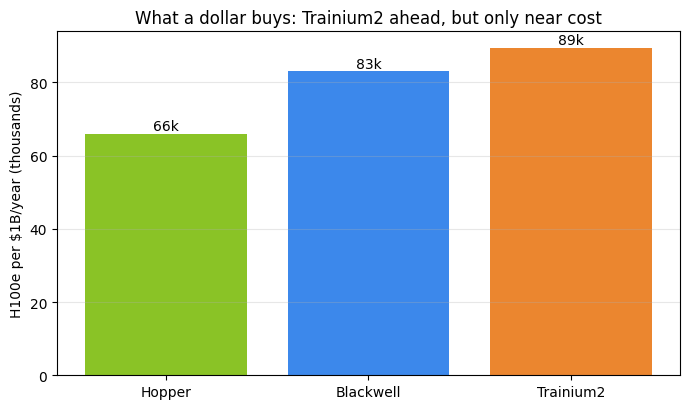

In [15]:
fig, ax = plt.subplots(figsize=(7, 4.2))
medians = {name: np.median(arr) for name, arr in buckets_per_b.items()}
ax.bar(list(medians), [v / 1e3 for v in medians.values()],
       color=[BUCKET_COLORS[n] for n in medians], alpha=0.85)
for col, value in enumerate(medians.values()):
    ax.text(col, value / 1e3 + 1, f'{value / 1e3:,.0f}k', ha='center', fontsize=10)
ax.set_ylabel('H100e per $1B/year (thousands)')
ax.set_title('What a dollar buys: Trainium2 ahead, but only near cost', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 7. Spend

The 2025 total and the end-2025 run-rate come from the section 1 samples. Sections 8–11 use the total (full-year average); section 12 uses the run-rate (snapshot).

In [16]:
spend = spend_2025_total        # sections 8-11: the full-year average
spend_2025_end = runrate_2025_end  # section 12: the end-2025 snapshot

lo, mid, hi = percentiles(spend)
print(f'2025 full-year total ($B):    {lo / 1e9:.2f} / {mid / 1e9:.2f} / {hi / 1e9:.2f}')
lo, mid, hi = percentiles(spend_2025_end)
print(f'End-2025 annualized run-rate: {lo / 1e9:.2f} / {mid / 1e9:.2f} / {hi / 1e9:.2f}')
print(f'   year-end / full-year average: {np.median(spend_2025_end) / np.median(spend):.2f}x (median)')

2025 full-year total ($B):    5.66 / 6.78 / 8.18
End-2025 annualized run-rate: 8.90 / 11.51 / 15.22
   year-end / full-year average: 1.70x (median)


## 8. The model

Spend splits into Trainium2 and Nvidia slices by the Trainium2 share. Within Nvidia, the dollar split between Hopper and Blackwell is set so the chip counts keep the borrowed count ratio. Each slice converts dollars to chips (dollars ÷ price ÷ 8,760) and on to H100e.

In [17]:
# With a Hopper:Blackwell count ratio of r:1 and per-hour prices, the share of
# Nvidia dollars going to Hopper is fixed (r Hoppers cost r*price_H, one Blackwell
# costs price_B). This varies per sample because prices do.
hopper_spend_share = (hopper_per_blackwell * hopper_price) / (
    hopper_per_blackwell * hopper_price + blackwell_price)

def anthropic_spend_h100e(total_spend, trainium_spend_share):
    """Annual-average H100e by bucket for the given spend (array) and Trainium2
    share of spend (scalar). Returns per-bucket H100e arrays plus totals."""
    trainium_spend = total_spend * trainium_spend_share
    nvidia_spend = total_spend * (1 - trainium_spend_share)

    # Trainium2 slice.
    trainium_chips = trainium_spend / trainium_price / HOURS_PER_YEAR
    trainium_h100e = trainium_chips * TRAINIUM2_H100E

    # Nvidia slice, split into Hopper and Blackwell.
    hopper_chips = nvidia_spend * hopper_spend_share / hopper_price / HOURS_PER_YEAR
    blackwell_chips = nvidia_spend * (1 - hopper_spend_share) / blackwell_price / HOURS_PER_YEAR
    hopper_h100e = hopper_chips * HOPPER_H100E
    blackwell_h100e = blackwell_chips * BLACKWELL_H100E

    chips = {'Hopper': hopper_chips, 'Blackwell': blackwell_chips, 'Trainium2': trainium_chips}
    h100e = {'Hopper': hopper_h100e, 'Blackwell': blackwell_h100e, 'Trainium2': trainium_h100e}
    return {
        'chips': chips,
        'h100e': h100e,
        'total_chips': sum(chips.values()),
        'total_h100e': sum(h100e.values()),
    }

## 9. Central estimate and the Trainium2-share sweep

Central assumption: Trainium2 takes 55% of spend (below its compute share, since it is cheaper per chip-hour). The share is then swept from 0 to 90%.

In [18]:
CENTRAL_TRAINIUM_SHARE = 0.55
central = anthropic_spend_h100e(spend, CENTRAL_TRAINIUM_SHARE)

lo, mid, hi = percentiles(central['total_h100e'])
print(f'Central estimate at {CENTRAL_TRAINIUM_SHARE:.0%} Trainium2 spend share '
      f'(2025 full-year average H100e):')
print(f'   5th / median / 95th = {fmt(lo)} / {fmt(mid)} / {fmt(hi)}\n')
print('   Median H100e by bucket:')
for name in ('Hopper', 'Blackwell', 'Trainium2'):
    print(f'      {name:10s}: {fmt(np.median(central["h100e"][name]))}')

Central estimate at 55% Trainium2 spend share (2025 full-year average H100e):
   5th / median / 95th = 447k / 570k / 721k

   Median H100e by bucket:
      Hopper    : 86k
      Blackwell : 146k
      Trainium2 : 335k


In [19]:
sweep_shares = np.round(np.arange(0.0, 0.901, 0.05), 2)
table_shares = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
sweep = {share: anthropic_spend_h100e(spend, share) for share in sweep_shares}

print(f'{"Trainium2 spend share":>22}   {"H100e (5th / median / 95th)":>30}')
print('-' * 58)
for share in table_shares:
    lo, mid, hi = percentiles(sweep[share]['total_h100e'])
    print(f'{share * 100:>20.0f}%   {fmt(lo):>9} /{fmt(mid):>9} /{fmt(hi):>9}')

 Trainium2 spend share      H100e (5th / median / 95th)
----------------------------------------------------------
                   0%        410k /     516k /     648k
                  10%        421k /     525k /     655k
                  20%        431k /     535k /     666k
                  30%        438k /     545k /     677k
                  40%        442k /     555k /     692k
                  50%        446k /     564k /     711k
                  60%        449k /     574k /     731k
                  70%        452k /     583k /     751k
                  80%        454k /     592k /     773k
                  90%        453k /     601k /     795k


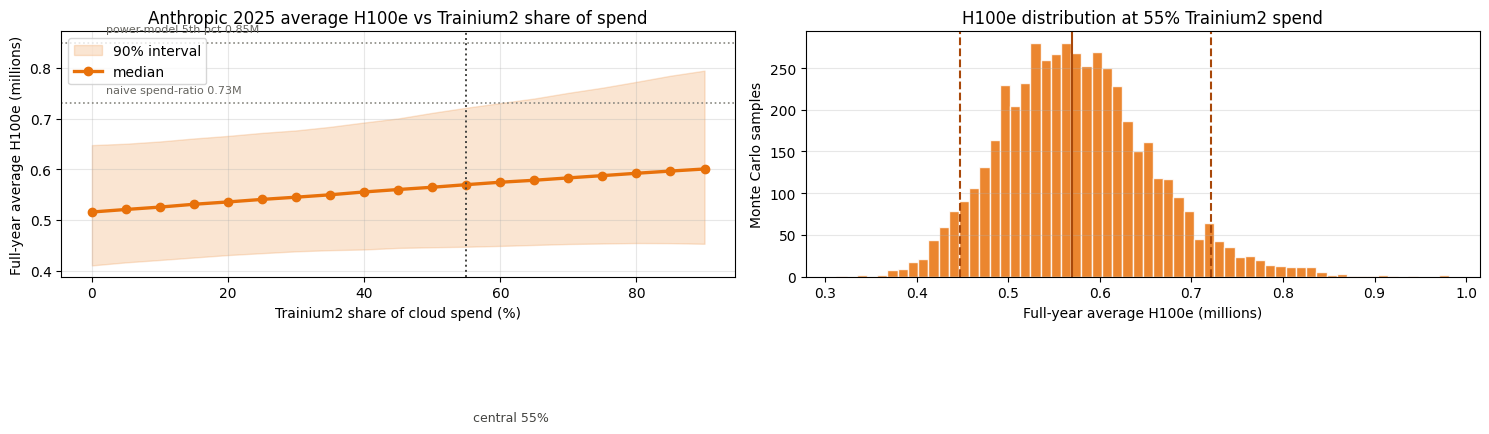

In [20]:
fig, (ax_curve, ax_hist) = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: H100e across the Trainium2 spend-share sweep, with the 90% band.
median_curve = np.array([np.median(sweep[s]['total_h100e']) for s in sweep_shares]) / 1e6
low_curve = np.array([percentiles(sweep[s]['total_h100e'])[0] for s in sweep_shares]) / 1e6
high_curve = np.array([percentiles(sweep[s]['total_h100e'])[2] for s in sweep_shares]) / 1e6

ax_curve.fill_between(sweep_shares * 100, low_curve, high_curve, color='#e8710a', alpha=0.18,
                      label='90% interval')
ax_curve.plot(sweep_shares * 100, median_curve, color='#e8710a', lw=2.4, marker='o', label='median')
ax_curve.axvline(CENTRAL_TRAINIUM_SHARE * 100, color='#444441', ls=':', lw=1.4)
ax_curve.text(CENTRAL_TRAINIUM_SHARE * 100 + 1, median_curve[0] * 0.2,
              'central 55%', fontsize=9, color='#444441')

# Outside anchors, for orientation: the naive spend-ratio scaling and the power
# model's end-2025 5th percentile (~0.85M after the 7/30 prior widening).
for value, text in [(0.73, 'naive spend-ratio 0.73M'), (0.85, 'power-model 5th pct 0.85M')]:
    ax_curve.axhline(value, color='#888780', ls=':', lw=1.2)
    ax_curve.text(2, value + 0.02, text, fontsize=8, color='#666560')

ax_curve.set_title('Anthropic 2025 average H100e vs Trainium2 share of spend', fontsize=12)
ax_curve.set_xlabel('Trainium2 share of cloud spend (%)')
ax_curve.set_ylabel('Full-year average H100e (millions)')
ax_curve.legend(loc='upper left')
ax_curve.grid(True, alpha=0.3)

# Right: the H100e distribution at the central share.
ax_hist.hist(central['total_h100e'] / 1e6, bins=60, color='#e8710a', alpha=0.85, edgecolor='white')
for value, style in zip(percentiles(central['total_h100e']), ['--', '-', '--']):
    ax_hist.axvline(value / 1e6, color='#a8480a', ls=style, lw=1.5)
ax_hist.set_title(f'H100e distribution at {CENTRAL_TRAINIUM_SHARE:.0%} Trainium2 spend', fontsize=12)
ax_hist.set_xlabel('Full-year average H100e (millions)')
ax_hist.set_ylabel('Monte Carlo samples')
ax_hist.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 10. Cross-check: implied Trainium2 chip count

Each spend share implies a full-year-average Trainium2 count, for comparison with the several hundred thousand chips at Project Rainier and the Mississippi campus at year-end (year-end figures, so the average should sit lower).

In [21]:
print(f'{"Trainium2 spend share":>22} {"Total H100e (median)":>20} {"Trainium2 chips (median)":>26}')
print('-' * 72)
for share in table_shares:
    total_med = np.median(sweep[share]['total_h100e'])
    trainium_chips_med = np.median(sweep[share]['chips']['Trainium2'])
    print(f'{share * 100:>20.0f}%   {fmt(total_med):>17}   {fmt(trainium_chips_med):>23}')

 Trainium2 spend share Total H100e (median)   Trainium2 chips (median)
------------------------------------------------------------------------
                   0%                516k                        0k
                  10%                525k                       93k
                  20%                535k                      186k
                  30%                545k                      279k
                  40%                555k                      371k
                  50%                564k                      464k
                  60%                574k                      557k
                  70%                583k                      650k
                  80%                592k                      743k
                  90%                601k                      836k


## 11. What drives the uncertainty

At the central share, each input varied alone with the others at their medians.

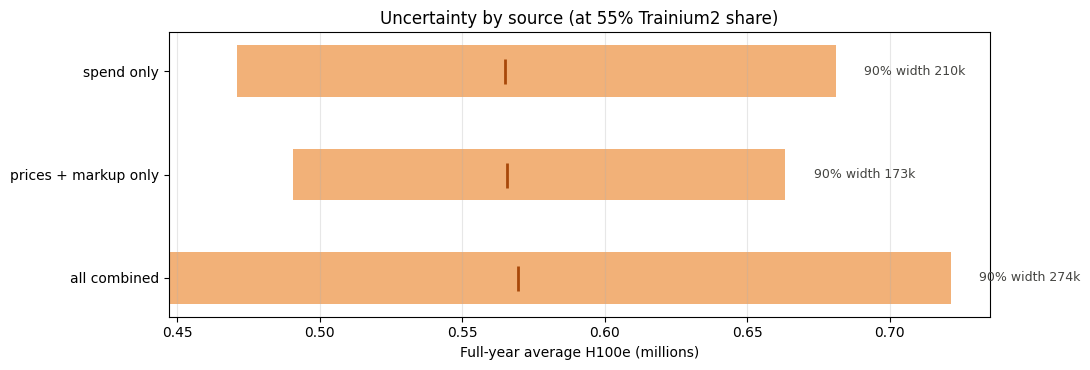

Full-year average H100e by source (5th / median / 95th):
   spend only              : 471k / 565k / 681k
   prices + markup only    : 491k / 566k / 663k
   all combined            : 447k / 570k / 721k


In [22]:
median_spend = float(np.median(spend))

def with_fixed_prices():
    """H100e at the central share with prices/markup held at their medians, so
    only spend varies."""
    global hopper_price, blackwell_price, trainium_price, hopper_spend_share
    saved = (hopper_price, blackwell_price, trainium_price, hopper_spend_share)
    hopper_price = np.full(N_SAMPLES, np.median(saved[0]))
    blackwell_price = np.full(N_SAMPLES, np.median(saved[1]))
    trainium_price = np.full(N_SAMPLES, np.median(saved[2]))
    hopper_spend_share = (hopper_per_blackwell * hopper_price) / (
        hopper_per_blackwell * hopper_price + blackwell_price)
    out = anthropic_spend_h100e(spend, CENTRAL_TRAINIUM_SHARE)
    hopper_price, blackwell_price, trainium_price, hopper_spend_share = saved
    return out

def with_fixed_spend():
    """H100e at the central share with spend held at its median, so only
    prices/markup vary."""
    return anthropic_spend_h100e(np.full(N_SAMPLES, median_spend), CENTRAL_TRAINIUM_SHARE)

decomposition = {
    'spend only': with_fixed_prices(),
    'prices + markup only': with_fixed_spend(),
    'all combined': central,
}

fig, ax = plt.subplots(figsize=(11, 3.8))
sources = list(decomposition)
for row, name in enumerate(sources):
    lo, mid, hi = percentiles(decomposition[name]['total_h100e'])
    ax.barh(row, (hi - lo) / 1e6, left=lo / 1e6, color='#e8710a', alpha=0.55, height=0.5)
    ax.plot(mid / 1e6, row, marker='|', color='#a8480a', markersize=18, markeredgewidth=2)
    ax.text((hi) / 1e6 + 0.01, row, f'90% width {fmt(hi - lo)}', va='center', fontsize=9, color='#444441')
ax.set_yticks(range(len(sources)))
ax.set_yticklabels(sources)
ax.invert_yaxis()
ax.set_xlabel('Full-year average H100e (millions)')
ax.set_title(f'Uncertainty by source (at {CENTRAL_TRAINIUM_SHARE:.0%} Trainium2 share)', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('Full-year average H100e by source (5th / median / 95th):')
for name in sources:
    lo, mid, hi = percentiles(decomposition[name]['total_h100e'])
    print(f'   {name:24s}: {fmt(lo)} / {fmt(mid)} / {fmt(hi)}')

## 12. End-2025 snapshot

The same model fed the end-2025 run-rate instead of the full-year total. The model is linear in spend, so this is the average scaled by the year-end-to-average ratio, with the growth-shape uncertainty attached.

In [23]:
central_end = anthropic_spend_h100e(spend_2025_end, CENTRAL_TRAINIUM_SHARE)
sweep_end = {share: anthropic_spend_h100e(spend_2025_end, share) for share in sweep_shares}

lo, mid, hi = percentiles(central_end['total_h100e'])
print(f'End-2025 SNAPSHOT at {CENTRAL_TRAINIUM_SHARE:.0%} Trainium2 spend share:')
print(f'   5th / median / 95th = {fmt(lo)} / {fmt(mid)} / {fmt(hi)}')
avg_mid = np.median(central['total_h100e'])
print(f'   (vs full-year average median {fmt(avg_mid)} from section 9)\n')

print(f'{"Trainium2 spend share":>22}   {"End-2025 snapshot H100e (5th / median / 95th)":>30}')
print('-' * 62)
for share in table_shares:
    lo, mid, hi = percentiles(sweep_end[share]['total_h100e'])
    print(f'{share * 100:>20.0f}%   {fmt(lo):>9} /{fmt(mid):>9} /{fmt(hi):>9}')

End-2025 SNAPSHOT at 55% Trainium2 spend share:
   5th / median / 95th = 713k / 964k / 1.32M
   (vs full-year average median 570k from section 9)

 Trainium2 spend share   End-2025 snapshot H100e (5th / median / 95th)
--------------------------------------------------------------
                   0%        648k /     874k /    1.19M
                  10%        663k /     890k /    1.20M
                  20%        677k /     906k /    1.22M
                  30%        690k /     922k /    1.25M
                  40%        701k /     938k /    1.28M
                  50%        709k /     955k /    1.31M
                  60%        718k /     972k /    1.34M
                  70%        723k /     988k /    1.38M
                  80%        726k /    1.00M /    1.41M
                  90%        726k /    1.02M /    1.44M


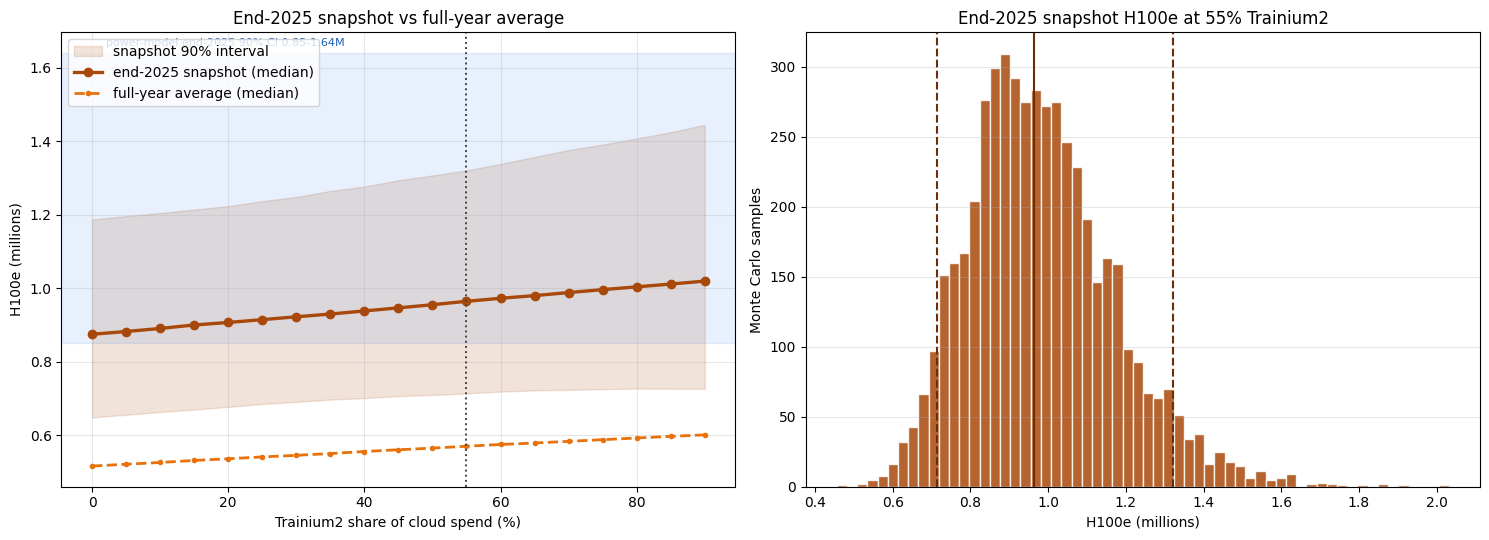

In [24]:
fig, (ax_curve, ax_hist) = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: average vs end-2025 snapshot across the Trainium share sweep.
avg_med = np.array([np.median(sweep[s]['total_h100e']) for s in sweep_shares]) / 1e6
end_med = np.array([np.median(sweep_end[s]['total_h100e']) for s in sweep_shares]) / 1e6
end_lo = np.array([percentiles(sweep_end[s]['total_h100e'])[0] for s in sweep_shares]) / 1e6
end_hi = np.array([percentiles(sweep_end[s]['total_h100e'])[2] for s in sweep_shares]) / 1e6

ax_curve.fill_between(sweep_shares * 100, end_lo, end_hi, color='#a8480a', alpha=0.15,
                      label='snapshot 90% interval')
ax_curve.plot(sweep_shares * 100, end_med, color='#a8480a', lw=2.4, marker='o', label='end-2025 snapshot (median)')
ax_curve.plot(sweep_shares * 100, avg_med, color='#e8710a', lw=2.0, ls='--', marker='.',
              label='full-year average (median)')
# Power-model end-2025 90% CI, for orientation (0.85-1.64M after 7/30 widening).
ax_curve.axhspan(0.85, 1.64, color='#1a73e8', alpha=0.10)
ax_curve.text(2, 1.66, 'power-model end-2025 90% CI 0.85-1.64M', fontsize=8, color='#1a5fb4')
ax_curve.axvline(CENTRAL_TRAINIUM_SHARE * 100, color='#444441', ls=':', lw=1.4)
ax_curve.set_title('End-2025 snapshot vs full-year average', fontsize=12)
ax_curve.set_xlabel('Trainium2 share of cloud spend (%)')
ax_curve.set_ylabel('H100e (millions)')
ax_curve.legend(loc='upper left')
ax_curve.grid(True, alpha=0.3)

# Right: snapshot distribution at the central share.
ax_hist.hist(central_end['total_h100e'] / 1e6, bins=60, color='#a8480a', alpha=0.85, edgecolor='white')
for value, style in zip(percentiles(central_end['total_h100e']), ['--', '-', '--']):
    ax_hist.axvline(value / 1e6, color='#6b2e08', ls=style, lw=1.5)
ax_hist.set_title(f'End-2025 snapshot H100e at {CENTRAL_TRAINIUM_SHARE:.0%} Trainium2', fontsize=12)
ax_hist.set_xlabel('H100e (millions)')
ax_hist.set_ylabel('Monte Carlo samples')
ax_hist.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Bottom line

- **Part A, end-2024: ~206k H100e** (90% CI ~141k–297k). The experimental backcast runs ~1.2× higher.
- **Part B, end-2025 snapshot: ~970k H100e** (90% CI ~0.7M–1.4M) at a 55% Trainium2 spend share, in the lower half of the power model's 0.84M–1.72M band. The Trainium2 markup is the main swing factor beyond spend itself.